# Layer Normalization

We have layer normalization at multiple places 

    1. With in the transformer block at multiple places
    2. Outside of transformer blocks

In GPT-2 and modern transformer architectures, layer normalization is typically applied before and after the multi head attention module and before the final output layer

#### Why do we have layer normalization

1. Training deep neural networks with many layers can be challenging due to vanishing or exploding gradients
2. This leads to unstable training dynamics
3. Layer Normalization improves the stability and efficiency of neural network training

1. As the training proceeds, inputs to each layer can change (internal covariance shift), this delays convergence

#### What is exploding/vanishing gradients problem

1. In the neural network back propagation, if the output of a layer is very high/very small, the gradient ofloss with respect to weights of the layer will also be very high/small

2. If the gradient is too small, it will not update neural network parameters

3. if the gradient is too large, it will lead to unstable training

4. Batch Normalization keeps gradients stable


### Main Idea - Adjust outputs of neural network to have mean zero and variance of one

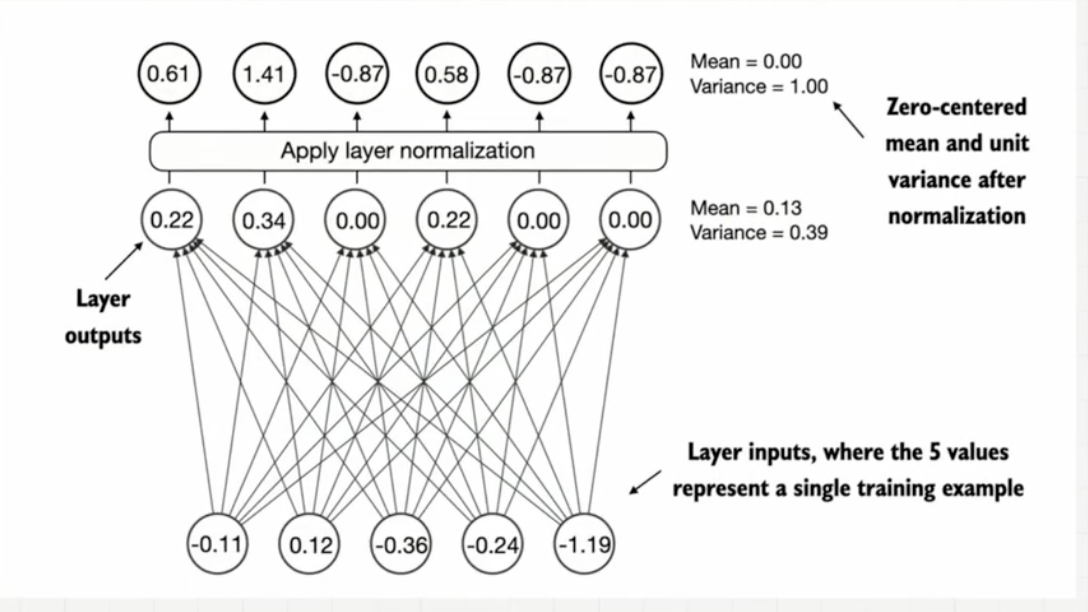

### Example

In [3]:
import torch
import torch.nn as nn
torch.manual_seed(123)

## we have 2 batches each with 5 inputs
batch_example = torch.randn(2, 5) #A
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


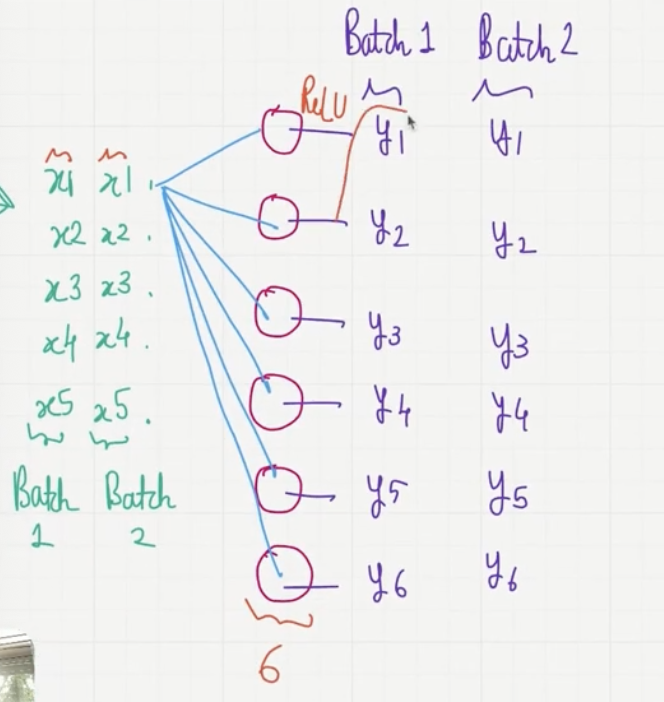

In [6]:
## for each layer, we apply layer normalization
# y_i = (y_i - mean)/(sqrt(variance))

In [9]:
## out - batch_size * input_size
mean = out.mean(dim=-1,keepdim=True)
var = out.var(dim=-1,keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [10]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [12]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(enb_dim))

    def forward(self,x):
        mean = x.mean(dim=-1,keepdim=True)

        ## unbiased=True - for Bessel's correction
        var = x.var(dim=-1,keepdim=True, unbiased=False)
        norm_x = (x-mean)/ torch.sqrt(var+self.eps)
        return self.scale * norm_x + self.shift


## Scale and Shift

The scale and shift are two trainable parameters (of the same dimension as the input) that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task.

This allows the model to learn appropriate scaling and shifting that best suit the data it is processing.

### Layer vs Batch
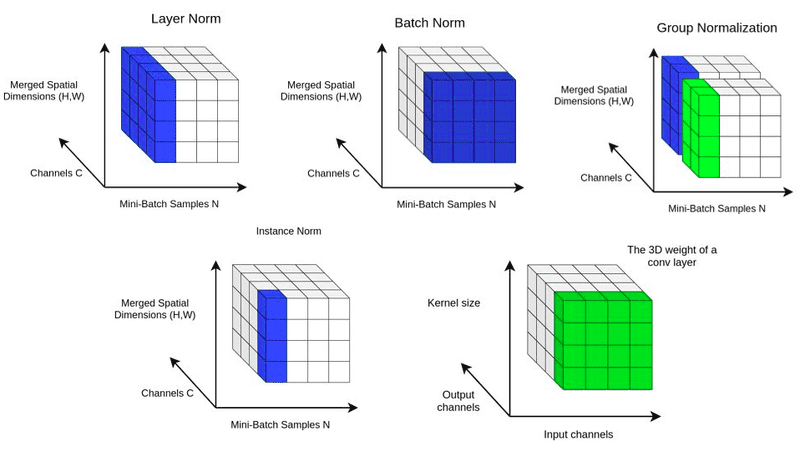

Layer Normalization - Along feature dimension

Batch Normalization - Along batch (depends on batch size)